In [2]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data
df = pd.read_parquet('ready_data_2.parquet')
df.head()


,TransactionId,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,EnergyClass,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,56.742153,16.291778,48,143,480,36,0,60.0,0.125,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,57.278909,13.646019,54,120,750,32,0,114.0,0.125,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,58.328009,15.103299,47,169,592,30,0,0.0,0.000,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,57.739437,14.122176,128,250,3311,30,0,88.0,0.375,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,57.784585,16.146614,112,87,3406,28,0,101.0,0.500,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [3]:
def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i

    return del_data, del_idx


def normalize_feature(feature):
    """Min-max normalization. This retains the relative position of the data points."""
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature)), np.max(feature), np.min(feature)


def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    normalization_variables = np.zeros((2, np.shape(data)[1])) # row 1: max value, row 2: min value

    for i in range(data.shape[axis]):
        norm_data[:,i], normalization_variables[0, i], normalization_variables[1, i] = normalize_feature(data[:,i])
    return norm_data, normalization_variables


def clustering(data, cluster_size=10, min_samples=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=min_samples ,  metric=distance_type)    # , approx_min_span_tree=True, algorithm='boruvka_balltree'
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)





def reduce_dimension(vector,clusters):
    """Takes a vector and a set of clusters and reduces the vectors dimension to the number of clusters using the clusters as a basis."""
    # Vector projection
    transformation_matrix = np.zeros([len(clusters), len(vector)])

    for i in clusters:
        transformation_matrix[i] = center_of_mass(clusters[i])

    reduced_vector = transformation_matrix * vector
    return reduced_vector


def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)


def compare_Euclidean(reference, comparables, k=3):
    """Takes a reference point and a matrix of comparable points and returns the first column of the comparable points (ID) and
    the Euclidean distances sorted by distance from low to high."""

    sq_compare = np.square(comparables[:,1:] - reference[1:])
    sum_compare = np.sum(sq_compare, axis=1)
    Euc_compare = np.sqrt(sum_compare)
    Euc_compare = np.vstack((comparables[:, 0], Euc_compare)).T

    sorted_dis = Euc_compare[Euc_compare[:, 1].argsort()]   # Sort Euc_compare

    return sorted_dis[0:k, :]

def show_clusters_in_latlon(data, sorted_clusters, number_of_clusters, clusterspan, lat_index=2, lon_index=3):
    """Creates a 3D plot of the clusters and their center of mass."""

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes()
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), lat_index]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), lon_index]
        ax.scatter(x1, y1, c = cmap(i), s = 1)

    ax.set_title('Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)

In [4]:
# Chaning to numpy array
def dataframe_to_numpy(dataframe):
    dataframe = dataframe.fillna(0)
    data = dataframe.to_numpy()


    data, removed_indices = remove_non_numbers(data)
    print("Removed indices:", removed_indices)



    data = data.astype(float) # Changing from type object to float so that numpy functions work properly.
    return data

Transaction_ID = df.iloc[:, 0]
# Transaction_ID = Transaction_ID.to_numpy()
# Transaction_ID = Transaction_ID.astype(np.float64)
# print(f'ID0: {Transaction_ID}, type: ')
# df = df.drop("TransactionId", axis=1)

data = dataframe_to_numpy(df)



# Divide the data set into training and testing data
percent = 0.10  # Fraction used for testing
samples = int(np.shape(data)[0] * percent)

training_data, testing_data = train_test_split(data, test_size=samples)

samples_2 = int(np.shape(training_data)[0]*percent)
training_data, validation_data = train_test_split(training_data, test_size=samples_2, random_state=42)

print('X1 shape: ', training_data.shape)
print('X3 shape: ', validation_data.shape)
print('X2 shape: ', testing_data.shape)

Removed indices: {0: 0}
X1 shape:  (74221, 164)
X3 shape:  (8246, 164)
X2 shape:  (9163, 164)


In [5]:
# Normalizing the data
norm_data, normalization_variables = normalize(training_data[0:200, :])
print(np.shape(norm_data))

(200, 164)


# Clustering

In [6]:

def create_clusterspan(sorted_clusters, number_of_clusters):
    clusterspan = np.zeros(number_of_clusters+2)

    for i in range(0, number_of_clusters+1):
        clusterspan[i+1] = clusterspan[i] + np.shape(sorted_clusters[np.where(sorted_clusters[:,0] == i)])[0]

    clusterspan[-1] = np.shape(sorted_clusters)[0]
    return clusterspan

def cluster_silhouette(clusterdata, CS, cluster_index):
    current_cluster = clusterdata[int(CS[cluster_index]):int(CS[cluster_index+1]), :]
    n = np.shape(current_cluster)[0] # Data points in current cluster
    
    OCS = np.delete(CS, cluster_index+1)
    OCS[cluster_index+1:] -= n
    other_clusters = np.delete(clusterdata.copy(), np.s_[int(CS[cluster_index]):int(CS[cluster_index+1])], axis=0)

    
    dis_cur_cluster = 0
    NoOC = np.shape(OCS)[0]-2 # NoOC = number of other clusters
    dis_cluster = np.zeros(NoOC)
    dis_near_cluster = 0.0

    for j in range(0, n):
        ref_point = current_cluster[j, :]
        dis_cur_cluster += np.sum(compare_Euclidean(ref_point, current_cluster)[:, 1]) / n
        
        for l in range(1, NoOC+1):
            nearest_cluster = other_clusters[int(OCS[l]):int(OCS[l+1]), :]
            m = np.shape(nearest_cluster)[0] # Data points in nearest cluster
            dis_cluster[l-1] = np.sum(compare_Euclidean(ref_point, nearest_cluster)[:, 1]) / m

        dis_near_cluster += np.min(dis_cluster, axis=0)


    try:
        average_silhouette = (dis_near_cluster - dis_cur_cluster) / np.maximum(dis_near_cluster, dis_cur_cluster)
        return average_silhouette
    except FloatingPointError:
        print('Current cluster:', current_cluster, 'Dis near:', dis_near_cluster, 'Dis cur:', dis_cur_cluster)

    return 0.0

def Silhouette(SC, NoC, CS):
    # SC = sorted clusters, NoC = number of clusters, CoM = centers of mass, CS = clusterspan
    average_silhouette_clusters = np.zeros((NoC, 2))

    # Find nearest cluster
    for i in range(1, NoC+1):
        average_silhouette_clusters[i-1, :] = i, cluster_silhouette(SC, CS, i)
    
    average_overall_silhouette = np.sum(average_silhouette_clusters[:, 1]) / NoC
    return average_overall_silhouette, average_silhouette_clusters


def optimal_cluster_size(data, max_MCS = 9000, min_MCS = 2000, step_size = 1000, max_recursion = 7, recursion = 0, first_calc=0):
    print(f'Recursion: {recursion}')
    backup = min_MCS 
    
    if first_calc !=0:
        min_MCS = first_calc
    
    max_iterations = (max_MCS-min_MCS) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))

    cluster_mat = np.zeros((np.shape(data)[0], np.shape(data)[1]+1, max_iterations)) # For saving results

    best_silhouette = -1
    best_index = 0
    best_cluster_index = 0

    for MCS in range(min_MCS, max_MCS+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        print(f'min: {min_MCS}, max: {max_MCS}, step size: {step_size}')
        index = (MCS-min_MCS)//step_size

        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        clustered_data[:, 0] += 1
        cluster_mat[:,:, index] = clustered_data

        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            print(f'{MCS} skipped because number of clusters < 2.')
            break
        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)

        average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, clusterspan)
        # print(f'Cluster silhouettes: {cluster_silhouettes}')

        if average_silhouette > best_silhouette:
            best_silhouette, best_index, best_cluster_index = average_silhouette, index, np.argmax(cluster_silhouettes[:, 1])
        
        print(f'MCS: {MCS}, Silhouette: {average_silhouette} \n Cluster silhouettes: {cluster_silhouettes}')
        Sil_mat[index] = MCS, average_silhouette, number_of_clusters

    
    if best_silhouette == -1:
        print(f'Stop. Cannot cluster further.')
        return np.insert(data, 0, 1, axis=1)

    # print(Sil_mat)
    min_MCS = backup
    # b = a[np.where(a[1] < 3)]
    print(f'Best silhouette: {best_silhouette}, Best index: {best_index}, Best cluster index: {best_cluster_index}')
    cluster_mat_best = cluster_mat[:, :, best_index]
    print('NOC:', np.max(cluster_mat_best[:,0]))
    best_cluster = cluster_mat_best[np.where(cluster_mat_best[:, 0] == best_cluster_index)]
    remaining_clusters = cluster_mat_best[np.where(cluster_mat_best[:, 0] != best_cluster_index)]
    size_bc = np.shape(best_cluster)[0]
    size_rc = np.shape(remaining_clusters)[0]

    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        if  size_bc > min_MCS and size_bc > 3:
            # print(f'new max: {np.min([max_MCS, size_bc-2])}')
            partition_1 = optimal_cluster_size(best_cluster[:, 1:], np.min([max_MCS, size_bc-2]), np.min([min_MCS, int(size_bc/2)]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_1 = best_cluster

        if  size_rc > min_MCS and size_rc > 3:
            # print(f'new max: {np.min([max_MCS, size_rc-2])}')
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, int(size_rc/2)]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters

        if np.min(partition_1[:,0] == 0): # All points in partition_1 should belong to a cluster
            partition_1[:, 0] += 1
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters

    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if size_bc > 0:
        partition_2[:, 0] += np.max(partition_1[:,0]) 

    return np.vstack((partition_1, partition_2, partition_3))

# Normalizing the data
# norm_data, normalization_variables = normalize(training_data)
print(np.shape(norm_data))

optimal_clustering = optimal_cluster_size(norm_data, 20, 4, 2)
print(optimal_clustering)

(200, 164)
Recursion: 0
min: 4, max: 20, step size: 2
MCS: 4, Silhouette: 0.02329583859095713 
 Cluster silhouettes: [[ 1.          0.98951074]
 [ 2.         -0.94291906]]
min: 4, max: 20, step size: 2
MCS: 6, Silhouette: 0.4836692882336118 
 Cluster silhouettes: [[1.         0.47229595]
 [2.         0.29635831]
 [3.         0.68235361]]
min: 4, max: 20, step size: 2
MCS: 8, Silhouette: 0.2240427718704856 
 Cluster silhouettes: [[ 1.         -0.43091141]
 [ 2.          0.87899695]]
min: 4, max: 20, step size: 2
MCS: 10, Silhouette: 0.2240427718704856 
 Cluster silhouettes: [[ 1.         -0.43091141]
 [ 2.          0.87899695]]
min: 4, max: 20, step size: 2
MCS: 12, Silhouette: 0.2240427718704856 
 Cluster silhouettes: [[ 1.         -0.43091141]
 [ 2.          0.87899695]]
min: 4, max: 20, step size: 2
MCS: 14, Silhouette: 0.2240427718704856 
 Cluster silhouettes: [[ 1.         -0.43091141]
 [ 2.          0.87899695]]
min: 4, max: 20, step size: 2
MCS: 16, Silhouette: 0.2240427718704856

avg sil: -0.35639705160987184 [[ 1.         -0.48474238]
 [ 2.         -0.83400289]
 [ 3.         -0.44388015]
 [ 4.         -0.47734514]
 [ 5.         -0.79475006]
 [ 6.         -0.75189517]
 [ 7.         -0.93016054]
 [ 8.         -0.09521049]
 [ 9.         -0.66965303]
 [10.         -0.91897542]
 [11.         -0.92142333]
 [12.          1.        ]
 [13.          1.        ]
 [14.          0.75506489]
 [15.         -0.77898206]] argmax 11


/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_911/1615709636.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_911/1615709636.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


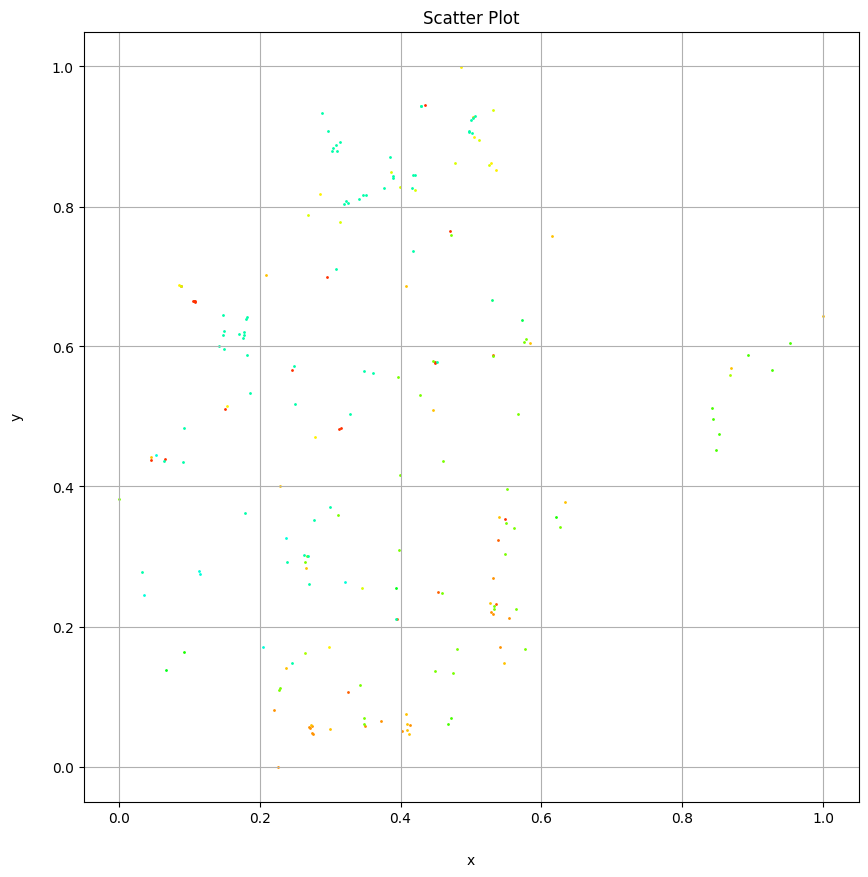

In [7]:
sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, clusterspan)
print('avg sil:', average_silhouette, cluster_silhouettes, 'argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [8]:
def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector

def center_of_mass(number_of_clusters, clusters):

    cluster_centers = np.zeros((number_of_clusters, np.shape(clusters)[1]))
    print(cluster_centers.shape)
    # print(clusters[np.where(clusters[:,0] == 1)])
    # balancing_vector = np.zeros_like
    for i in range(1, number_of_clusters+1):
        cluster_x = clusters[np.where(clusters[:,0] == i)]
        print(np.shape(cluster_x))
        cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]

    return cluster_centers


def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

centers_of_mass = center_of_mass(number_of_clusters, sorted_clusters)
print(centers_of_mass)
transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

# norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
print(np.shape(embedded_data))
# print(norm_embedded_data)

(15, 165)
(17, 165)
(6, 165)
(16, 165)
(22, 165)
(9, 165)
(11, 165)
(2, 165)
(33, 165)
(9, 165)
(2, 165)
(2, 165)
(1, 165)
(1, 165)
(62, 165)
(7, 165)
[[ 1.          0.59917707  0.25290932 ...  0.77084946  0.3045016
   0.81503859]
 [ 2.          0.28505104  0.46298763 ...  0.75164474  0.37083759
   0.79646832]
 [ 3.          0.10428986  0.37736606 ...  0.81409334  0.33352781
   0.88015068]
 ...
 [13.          0.66599994  0.53002073 ...  0.          0.20621547
   0.        ]
 [14.          0.6666735   0.29655607 ...  0.61105953  0.3295099
   0.65470892]
 [15.          0.2865963   0.15453203 ...  0.79757989  0.50962341
   0.81832124]]
(200, 15)


1 0.5991770715129652 0.2529093167450694 0.18964342493754258
2 0.2850510444456909 0.4629876280339829 0.20398970398970398
3 0.10428986136498651 0.37736605560487585 0.24010617760617764
4 0.3696591184192504 0.44853222731073994 0.29133029133029137
5 0.6974485711974763 0.3507511063513771 0.23509223509223506
6 0.7783797195229315 0.3880674157244778 0.279045279045279
7 0.3605021731739338 0.5663045734301161 0.31467181467181465
8 0.33221869157974937 0.4391550140156034 0.23095823095823098
9 0.4252105649273074 0.7886324200620692 0.25997425997426
10 0.26016779151734304 0.3572089141019844 0.1023166023166023
11 0.19610260965257154 0.23037787040213625 0.21042471042471042
12 0.6379930455571031 0.5722830496670394 0.11196911196911197
13 0.6659999423184845 0.5300207333506772 0.1274131274131274
14 0.6666735031700746 0.2965560730116236 0.1980321335160045
15 0.2865962951411671 0.15453202601486943 0.22945394373965802


/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_911/1615709636.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_911/4142778389.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_911/4142778389.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will ha

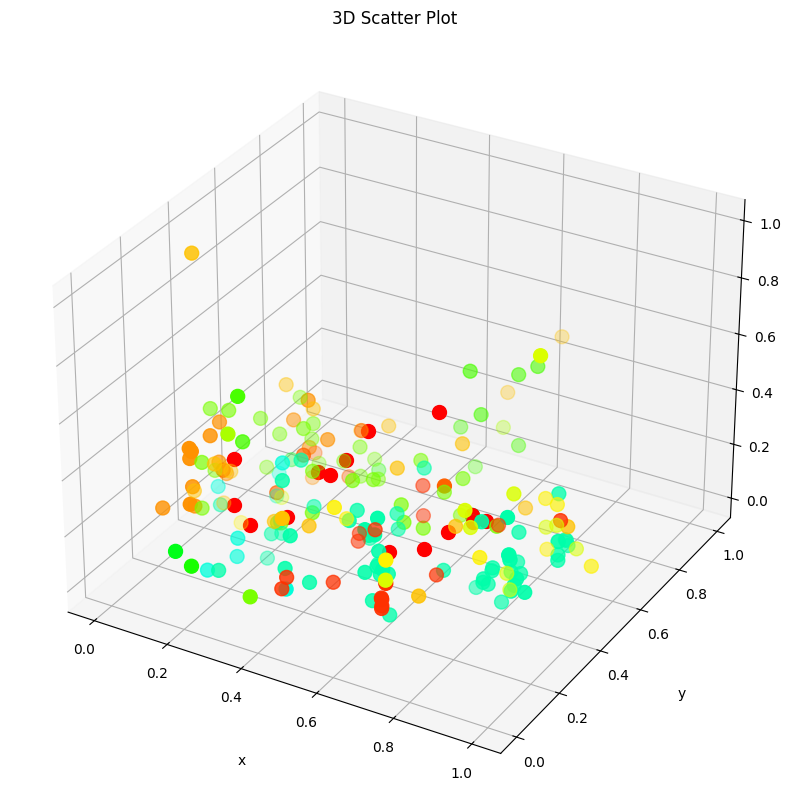

In [9]:
def show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan):
    """Creates a 3D plot of the clusters and their center of mass."""
    
    # %matplotlib widget

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 1]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 2]
        z1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 3]
        ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
        xc1,yc1,zc1 = centers_of_mass[i-1, 1:4]
        print(i, xc1, yc1, zc1)
        ax.scatter(xc1,yc1,zc1, c = cmap(-i), s = 100)

    # xc2,yc2,zc2 = centers_of_mass[1, 1:4]

    # print("1", xc1, yc1, zc1)
    # print("2", xc2, yc2, zc2)

    ax.set_title('3D Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)
    ax.set_zlabel('z', labelpad=20)

show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)

In [13]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        # self.iterations = iterations

    def fit(self, Data, Targets):
        n_samples, n_features = Data.shape
        self.weight = np.random.random(n_features) # np.zeros(n_features) # np.random.random((np.shape(Data[0,:])))
        print('before:', self.weight)
        self.bias = 0
        self.iterations = n_samples

        for _ in range(self.iterations):
            predict = np.dot(Data, self.weight) + self.bias
            # print(np.shape(Targets))
            # print(n_samples)
            dw = 1/n_samples * np.dot(Data.T, predict-Targets)
            db = 1/n_samples * np.sum(predict - Targets)

            self.weight -= self.lr * dw
            self.bias -= self.lr * db
        print('bias:', self.bias)
        print('after:', self.weight)

    def predict(self, testing_data):
        y_predict = np.dot(testing_data, self.weight) + self.bias
        return y_predict
    
    def mean_abs_e(self, y_true, y_pred):
        error = np.mean(np.abs(y_true - y_pred))
        print(f'true: {y_true}, pred: {y_pred}')
        return error
    
    def mse(self, y_true, y_pred):
        error = np.mean((y_true-y_pred)**2)
        return error

data_points = 200
Targets = training_data[0:data_points, 5]
# print(Targets.shape)
norm_Targets, max_targets, min_targets = normalize_feature(Targets)

norm_embedded_data = embedded_data
samples = np.shape(norm_embedded_data)[0]

train_data, testing_data = train_test_split(norm_embedded_data, test_size=0.20)
# print("train data", train_data)
train_targets, testing_targets = train_test_split(norm_Targets, test_size=0.20)

train_targets = norm_Targets
# print(norm_Targets)
train_data = embedded_data

regression = LinearRegression()
regression.fit(train_data, train_targets)
prediction = regression.predict(testing_data)

mse = regression.mse(testing_targets, prediction)

absolute = regression.mean_abs_e(testing_targets, prediction)

print(mse, absolute)


before: [0.57697676 0.15237041 0.61382552 0.38185577 0.2301974  0.89575395
 0.40174734 0.19466635 0.50277071 0.13053621 0.80881703 0.41794093
 0.17017312 0.27609292 0.40739589]
bias: 5.313032407736972e+81
after: [2.70451051e+82 2.68472241e+82 2.68452449e+82 2.76818877e+82
 2.59197171e+82 2.67593663e+82 2.61015765e+82 2.76533254e+82
 2.44171276e+82 2.53465477e+82 2.55693723e+82 2.41030218e+82
 2.22651513e+82 2.75104205e+82 2.61292777e+82]
true: [0.8        0.77142857 0.51428571 0.31428571 0.62857143 0.42857143
 0.48571429 0.42857143 0.54285714 0.57142857 0.82857143 0.4
 0.25714286 0.71428571 0.71428571 0.54285714 0.22857143 0.57142857
 0.62857143 0.74285714 0.4        0.54285714 0.6        0.77142857
 0.37142857 0.14285714 0.45714286 0.51428571 0.57142857 0.34285714
 0.65714286 0.51428571 0.37142857 0.6        0.65714286 0.48571429
 0.77142857 0.8        0.65714286 0.4       ], pred: [1.90630815e+84 1.72615193e+84 2.02489578e+84 1.90018034e+84
 2.05624842e+84 1.66433061e+84 1.58543693e+